# ARCA — Notebook Evaluasi & Analisis

**Artefact Reconstruction with Computer graphics Application**  
Repositori: https://github.com/luminolous/ARCA  
Live demo: https://lumicero-arca.static.hf.space

### Pemetaan ke pertanyaan penelitian (PRD §3 & §11)

| RQ | Pertanyaan | Dijawab oleh tahap |
|----|-----------|--------------------|
| **RQ1** | Generalisasi ke artefak budaya — kategori mana berhasil/gagal & kenapa | Tahap 2b (per-kategori), Tahap 3 (kualitas), Tahap 6 (failure), **Tahap 7 (SF3D vs TripoSR)** |
| **RQ2** | Keseimbangan kualitas / ukuran / kecepatan | Tahap 2 (performa), **Tahap 8 (ablation tier nyata)** |
| **RQ3** | Apakah PBR + delighting → relight masuk akal | **Tahap 8 (delight on/off)**, Tahap 5 (user study) |

Tahap **bertanda tebal** = baru (mengisi celah RQ1/RQ2/RQ3 yang sebelumnya belum terjawab). Tahap ablation/TripoSR auto-skip bila manifest-nya belum diisi di `KONFIGURASI`.

> **Catatan metode PSNR (Tahap 3):** PRD §11 mensyaratkan render ulang mesh **dari sudut kamera yang sama dengan foto input**. Screenshot viewer bersudut bebas → PSNR jadi tak sebanding (lihat caveat di Tahap 3). Proyek ini diposisikan *lebih cepat & murah*, **bukan lebih akurat** dari fotogrametri (PRD §6) — metrik kualitas bersifat pelengkap, bukan klaim utama.

---
## Tahap 0 — Setup & Konfigurasi

Isi variabel konfigurasi di bawah sesuai lokasi file di lingkunganmu.

In [30]:
# Install dependensi
# Jalankan sekali, lalu restart kernel jika diminta
import subprocess, sys

pkgs = [
    'scikit-image',
    'opencv-python-headless',
    'matplotlib',
    'pandas',
    'numpy',
    'requests',
    'tabulate',
    'seaborn',
]

for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('Semua dependensi berhasil diinstall.')

Semua dependensi berhasil diinstall.


In [ ]:
# ============================================================
#  KONFIGURASI — sesuaikan dengan lingkunganmu
# ============================================================

# URL manifest dari Hugging Face Space (sudah online)
MANIFEST_URL = 'https://huggingface.co/spaces/lumicero/arca/resolve/main/manifest.json'

# Jika punya file lokal, isi path-nya dan set USE_LOCAL_MANIFEST = True
USE_LOCAL_MANIFEST = False
LOCAL_MANIFEST_PATH = 'public/manifest.json'

# Direktori foto asli artefak (untuk PSNR/SSIM)
# Jika tidak punya, bagian PSNR/SSIM akan di-skip otomatis
PHOTOS_DIR = '/kaggle/input/datasets/nazhifberlian/gambar-real'   # ubah sesuai path dataset

# Direktori screenshot hasil viewer
# Hasilkan dengan klik tombol Capture di live demo, lalu simpan di folder ini
SCREENSHOTS_DIR = '/kaggle/input/datasets/nazhifberlian/gambar'

# Jumlah artefak yang dievaluasi untuk PSNR/SSIM (bisa subset)
N_EVAL_PSNR = 10

# --- Sumber tambahan untuk menjawab 3 pertanyaan penelitian (PRD §3 & §11) ---
# RQ1 kategori: categories.csv (object_id->kategori) dari repo pipeline.
CATEGORIES_URL = 'https://raw.githubusercontent.com/eycoo/FP_GRAFKOM/master/dataset/categories.csv'
CATEGORIES_LOCAL = '/kaggle/working/FP_GRAFKOM/dataset/categories.csv'
# RQ2/RQ3 ablation: manifest_ablation.jsonl dari notebook pipeline cell 5b (tier x delight).
ABLATION_MANIFEST = ''   # isi path/URL bila sudah dijalankan; '' = skip
# RQ1 pembanding model: manifest_triposr.jsonl dari notebook 03 (TripoSR).
TRIPOSR_MANIFEST = ''    # isi path/URL bila sudah dijalankan; '' = skip

# Output folder
OUTPUT_DIR = 'eval_output'

# ============================================================
import os, warnings
warnings.filterwarnings('ignore')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SCREENSHOTS_DIR, exist_ok=True)
print(f'Output akan disimpan di: {OUTPUT_DIR}/')

In [32]:
import json, requests, math, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from tabulate import tabulate
from datetime import datetime

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Import selesai.')

Import selesai.


---
## Tahap 1 — Muat Data Manifest

`manifest.json` berisi metadata semua artefak: waktu rekonstruksi, ukuran GLB, vertex count, dll.  
Data ini langsung tersedia di Hugging Face Space tanpa perlu menjalankan pipeline rekonstruksi.

In [33]:
# Muat manifest
if USE_LOCAL_MANIFEST and os.path.exists(LOCAL_MANIFEST_PATH):
    with open(LOCAL_MANIFEST_PATH) as f:
        manifest = json.load(f)
    print(f'Manifest lokal dimuat: {LOCAL_MANIFEST_PATH}')
else:
    print(f'Mengunduh manifest dari {MANIFEST_URL} ...')
    resp = requests.get(MANIFEST_URL, timeout=30)
    resp.raise_for_status()
    manifest = resp.json()
    print('Manifest berhasil diunduh.')

df = pd.DataFrame(manifest)

# Turunan kolom
df['glb_kb']   = df['glb_bytes'] / 1024
df['glb_mb']   = df['glb_bytes'] / (1024 ** 2)
df['tri_count'] = df.get('vertex_count', 10000) * 2  # estimasi triangle dari vertex

print(f'\nTotal artefak: {len(df)}')
print(f'Kolom tersedia: {list(df.columns)}')
df.head(5)

Mengunduh manifest dari https://huggingface.co/spaces/lumicero/arca/resolve/main/manifest.json ...
Manifest berhasil diunduh.

Total artefak: 60
Kolom tersedia: ['stem', 'input', 'glb', 'tier', 'seconds', 'peak_vram_gb', 'glb_bytes', 'raw_maps', 'foreground_ratio', 'texture_resolution', 'remesh', 'vertex_count', 'glb_kb', 'glb_mb', 'tri_count']


,stem,input,glb,tier,seconds,peak_vram_gb,glb_bytes,raw_maps,foreground_ratio,texture_resolution,remesh,vertex_count,glb_kb,glb_mb,tri_count
0,artefak_26824,/kaggle/input/datasets/ahmfras/data-fp-grafkom...,/kaggle/working/outputs/glb/artefak_26824_low.glb,low,4.944,6.065,424484,[],0.85,256,triangle,10000,414.535156,0.404819,20000
1,artefak_31220,/kaggle/input/datasets/ahmfras/data-fp-grafkom...,/kaggle/working/outputs/glb/artefak_31220_low.glb,low,5.855,6.065,474228,[],0.85,256,triangle,10000,463.113281,0.452259,20000
2,artefak_31399,/kaggle/input/datasets/ahmfras/data-fp-grafkom...,/kaggle/working/outputs/glb/artefak_31399_low.glb,low,6.997,6.065,486924,[],0.85,256,triangle,10000,475.511719,0.464367,20000
3,artefak_316457,/kaggle/input/datasets/ahmfras/data-fp-grafkom...,/kaggle/working/outputs/glb/artefak_316457_low...,low,5.467,6.065,439292,[],0.85,256,triangle,10000,428.996094,0.418941,20000
4,artefak_31781,/kaggle/input/datasets/ahmfras/data-fp-grafkom...,/kaggle/working/outputs/glb/artefak_31781_low.glb,low,5.104,6.065,426416,[],0.85,256,triangle,10000,416.421875,0.406662,20000


In [ ]:
# --- 1b. Kategori artefak (RQ1) ---
# Pakai kolom 'category' bila manifest baru sudah punya; kalau tidak, turunkan dari
# categories.csv (object_id->kategori) lalu join via stem artefak_<id>.
import re

def _stem_to_oid(s):
    m = re.search(r'(\d+)', str(s))
    return m.group(1) if m else ''

if 'category' in df.columns and df['category'].notna().any():
    print('Kategori diambil dari kolom manifest.')
else:
    cat_map = {}
    for src in (CATEGORIES_LOCAL, CATEGORIES_URL):
        try:
            cat_df = (pd.read_csv(src, dtype={'object_id': str}) if os.path.exists(str(src))
                      else pd.read_csv(src, dtype={'object_id': str}))
            cat_map = dict(zip(cat_df['object_id'].astype(str), cat_df['kategori']))
            print(f'Kategori dari {src} ({len(cat_map)} entri).')
            break
        except Exception as e:
            print(f'  gagal {src}: {str(e)[:50]}')
    df['category'] = df['stem'].map(lambda s: cat_map.get(_stem_to_oid(s), 'lainnya'))

print('\nDistribusi kategori:')
print(df['category'].value_counts().to_string())

In [ ]:
# --- 2b. Performa & distribusi per KATEGORI (RQ1) ---
# RQ1: "pada kategori apa berhasil/gagal". Di sini baseline performa per-kategori;
# kualitas per-kategori menyusul di Tahap 3 (PSNR) & Tahap 6 (failure).
CAT_ORDER = ['arca', 'senjata', 'wadah', 'ritual', 'arsitektur', 'lainnya']
cats = [c for c in CAT_ORDER if c in df['category'].unique()]

g = df.groupby('category').agg(
    N=('stem', 'count'),
    waktu_mean=('seconds', 'mean'),
    glb_kb_mean=('glb_kb', 'mean'),
).reindex(cats).round(2)
print('Performa per kategori:')
print(tabulate(g, headers=['Kategori', 'N', 'Waktu (s)', 'GLB (KB)'], tablefmt='rounded_outline'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(g.index, g['N'], color='#7F77DD', edgecolor='white')
axes[0].set_title('Jumlah artefak / kategori'); axes[0].set_ylabel('N')
axes[1].bar(g.index, g['waktu_mean'], color='#5DCAA5', edgecolor='white')
axes[1].set_title('Rata-rata waktu (s)')
axes[2].bar(g.index, g['glb_kb_mean'], color='#D85A30', edgecolor='white')
axes[2].set_title('Rata-rata GLB (KB)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('RQ1 — Profil per kategori artefak', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01b_per_kategori.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Plot disimpan: {OUTPUT_DIR}/01b_per_kategori.png')

---
## Tahap 2 — Analisis Performa Sistem

Mengukur: waktu rekonstruksi, VRAM, ukuran file, dan distribusi statistiknya.

In [34]:
# --- 2a. Statistik deskriptif ---
metrics_cols = ['seconds', 'peak_vram_gb', 'glb_kb', 'vertex_count']
labels = {
    'seconds':       'Waktu rekonstruksi (detik)',
    'peak_vram_gb':  'Peak VRAM (GB)',
    'glb_kb':        'Ukuran GLB (KB)',
    'vertex_count':  'Vertex count',
}

desc = df[metrics_cols].describe().T
desc.index = [labels[c] for c in desc.index]
desc.columns = ['N', 'Mean', 'Std', 'Min', 'Q1', 'Median', 'Q3', 'Max']
desc = desc.round(3)

print('=' * 70)
print('RINGKASAN PERFORMA SISTEM')
print('=' * 70)
print(tabulate(desc, headers='keys', tablefmt='rounded_outline'))
print()

# Artefak outlier (waktu > mean + 2*std)
thr = df['seconds'].mean() + 2 * df['seconds'].std()
outliers = df[df['seconds'] > thr][['stem', 'seconds', 'glb_kb']]
if len(outliers):
    print(f'Outlier waktu rekonstruksi (> {thr:.1f} detik):')
    print(tabulate(outliers, headers='keys', tablefmt='rounded_outline', showindex=False))
else:
    print('Tidak ada outlier waktu rekonstruksi.')

RINGKASAN PERFORMA SISTEM
╭────────────────────────────┬─────┬───────────┬────────┬───────────┬───────────┬───────────┬───────────┬───────────╮
│                            │   N │      Mean │    Std │       Min │        Q1 │    Median │        Q3 │       Max │
├────────────────────────────┼─────┼───────────┼────────┼───────────┼───────────┼───────────┼───────────┼───────────┤
│ Waktu rekonstruksi (detik) │  60 │     5.789 │  0.793 │     4.944 │     5.532 │     5.649 │     5.842 │    11.303 │
│ Peak VRAM (GB)             │  60 │     6.065 │  0     │     6.065 │     6.065 │     6.065 │     6.065 │     6.065 │
│ Ukuran GLB (KB)            │  60 │   445.086 │ 26.002 │   414.535 │   423.661 │   438.939 │   459.394 │   527.316 │
│ Vertex count               │  60 │ 10000     │  0     │ 10000     │ 10000     │ 10000     │ 10000     │ 10000     │
╰────────────────────────────┴─────┴───────────┴────────┴───────────┴───────────┴───────────┴───────────┴───────────╯

Outlier waktu rekonstruksi (>

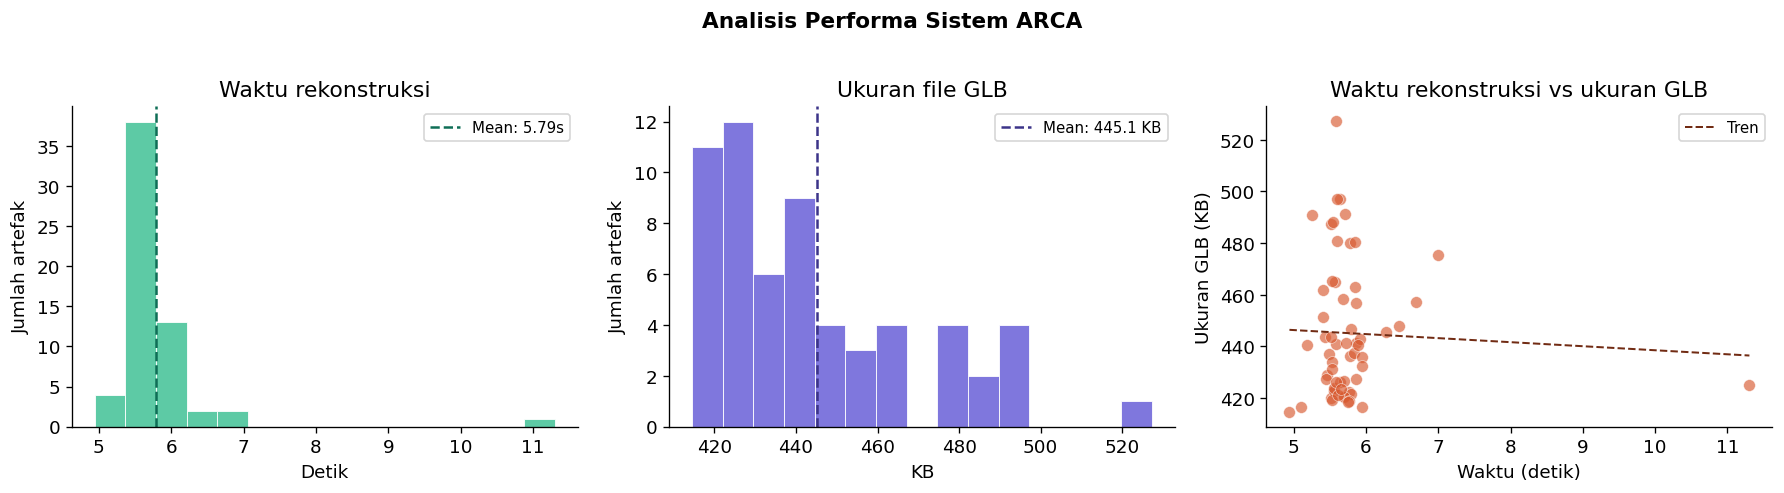

Plot disimpan: eval_output/01_performa_sistem.png


In [35]:
# --- 2b. Visualisasi distribusi performa ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Waktu rekonstruksi
ax = axes[0]
ax.hist(df['seconds'], bins=15, color='#5DCAA5', edgecolor='white', linewidth=0.5)
ax.axvline(df['seconds'].mean(), color='#0F6E56', linestyle='--', linewidth=1.5,
           label=f"Mean: {df['seconds'].mean():.2f}s")
ax.set_title('Waktu rekonstruksi')
ax.set_xlabel('Detik')
ax.set_ylabel('Jumlah artefak')
ax.legend(fontsize=9)

# Ukuran GLB
ax = axes[1]
ax.hist(df['glb_kb'], bins=15, color='#7F77DD', edgecolor='white', linewidth=0.5)
ax.axvline(df['glb_kb'].mean(), color='#3C3489', linestyle='--', linewidth=1.5,
           label=f"Mean: {df['glb_kb'].mean():.1f} KB")
ax.set_title('Ukuran file GLB')
ax.set_xlabel('KB')
ax.set_ylabel('Jumlah artefak')
ax.legend(fontsize=9)

# Scatter: waktu vs ukuran
ax = axes[2]
ax.scatter(df['seconds'], df['glb_kb'], alpha=0.65, color='#D85A30',
           edgecolors='white', linewidth=0.4, s=50)

# garis regresi
z = np.polyfit(df['seconds'], df['glb_kb'], 1)
p = np.poly1d(z)
xs = np.linspace(df['seconds'].min(), df['seconds'].max(), 100)
ax.plot(xs, p(xs), color='#712B13', linewidth=1.2, linestyle='--', label='Tren')
ax.set_title('Waktu rekonstruksi vs ukuran GLB')
ax.set_xlabel('Waktu (detik)')
ax.set_ylabel('Ukuran GLB (KB)')
ax.legend(fontsize=9)

fig.suptitle('Analisis Performa Sistem ARCA', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_performa_sistem.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Plot disimpan: {OUTPUT_DIR}/01_performa_sistem.png')

In [36]:
# --- 2c. Tabel performa per-artefak (top 10 terlambat) ---
top_slow = df.nlargest(10, 'seconds')[['stem','seconds','glb_kb','peak_vram_gb','vertex_count']].copy()
top_slow.columns = ['Artefak','Waktu (s)','GLB (KB)','VRAM (GB)','Vertex']
top_slow = top_slow.round(3)

print('10 Artefak dengan Waktu Rekonstruksi Terlama:')
print(tabulate(top_slow, headers='keys', tablefmt='rounded_outline', showindex=False))

# Simpan ke CSV
df.to_csv(f'{OUTPUT_DIR}/manifest_processed.csv', index=False)
print(f'\nData lengkap disimpan: {OUTPUT_DIR}/manifest_processed.csv')

10 Artefak dengan Waktu Rekonstruksi Terlama:
╭───────────────┬─────────────┬────────────┬─────────────┬──────────╮
│ Artefak       │   Waktu (s) │   GLB (KB) │   VRAM (GB) │   Vertex │
├───────────────┼─────────────┼────────────┼─────────────┼──────────┤
│ artefak_37621 │      11.303 │    424.863 │       6.065 │    10000 │
│ artefak_31399 │       6.997 │    475.512 │       6.065 │    10000 │
│ artefak_37699 │       6.691 │    457.121 │       6.065 │    10000 │
│ artefak_37727 │       6.458 │    447.719 │       6.065 │    10000 │
│ artefak_37749 │       6.28  │    445.684 │       6.065 │    10000 │
│ artefak_38273 │       5.953 │    436.039 │       6.065 │    10000 │
│ artefak_38178 │       5.95  │    416.426 │       6.065 │    10000 │
│ artefak_38282 │       5.948 │    432.207 │       6.065 │    10000 │
│ artefak_38266 │       5.919 │    443.043 │       6.065 │    10000 │
│ artefak_38289 │       5.889 │    440.602 │       6.065 │    10000 │
╰───────────────┴─────────────┴────────────┴

---
## Tahap 3 — Kualitas Render: PSNR & SSIM (+ LPIPS)

> **⚠️ Caveat metode (penting untuk laporan).** PRD §11 mensyaratkan: *render ulang mesh dari **sudut kamera yang sama** dengan foto input*, baru bandingkan. Screenshot viewer di sini bersudut bebas (pose, crop, latar, pencahayaan berbeda) → PSNR rendah (mis. 3–13 dB) **bukan** ukuran kegagalan model, melainkan akibat ketidaksejajaran. Angka ini hanya **indikasi kasar fidelity tampak-depan**, bukan klaim akurasi. Perbaikan benar = render dari pose kamera input (sisi viewer/Jobdesk 3) lalu hitung ulang. LPIPS (perseptual) ditambahkan sebagai pelengkap.

**Cara kerja (sementara):**
1. Buka live demo, pilih artefak → mode **Lit** → **Capture** → simpan PNG ke `SCREENSHOTS_DIR`.
2. Nama file = `<stem>_lit.png`, mis. `artefak_26824_lit.png`.
3. Sediakan foto asli di `PHOTOS_DIR` (`<stem>.jpg`).
4. Jalankan sel di bawah. Tanpa foto asli → tahap ini auto-skip.

In [37]:
# --- 3a. Cek ketersediaan data ---
screenshots = sorted(glob.glob(f'{SCREENSHOTS_DIR}/*_lit.png'))

psnr_available = False

if not screenshots:
    print('TIDAK ADA SCREENSHOT DITEMUKAN di folder:', SCREENSHOTS_DIR)
    print()
    print('Cara menghasilkan screenshot:')
    print('  1. Buka https://lumicero-arca.static.hf.space')
    print('  2. Klik artefak di gallery')
    print('  3. Pastikan mode "Lit" aktif di panel Inspect')
    print('  4. Klik tombol Capture (kamera) di pojok kanan bawah')
    print(f'  5. Simpan file ke folder: {SCREENSHOTS_DIR}/')
    print('  6. Jalankan sel ini kembali')
    print()
    print('Tahap 3 (PSNR/SSIM) akan di-skip. Lanjutkan ke Tahap 4.')
else:
    print(f'Ditemukan {len(screenshots)} screenshot:')
    for s in screenshots:
        print(f'  {s}')
    psnr_available = True

Ditemukan 3 screenshot:
  /kaggle/input/datasets/nazhifberlian/gambar/artefak_37414_lit.png
  /kaggle/input/datasets/nazhifberlian/gambar/artefak_37687_lit.png
  /kaggle/input/datasets/nazhifberlian/gambar/artefak_38994_lit.png


In [51]:
# --- 3b. Hitung PSNR & SSIM ---
psnr_results = []

if psnr_available:
    for ss_path in screenshots[:N_EVAL_PSNR]:
        stem = os.path.basename(ss_path).replace('_lit.png', '')

        # Cari foto asli
        ref_candidates = [
            os.path.join(PHOTOS_DIR, f'{stem}.jpg'),
            os.path.join(PHOTOS_DIR, f'{stem}.png'),
            os.path.join(PHOTOS_DIR, f'{stem}.jpeg'),
        ]
        ref_path = next((p for p in ref_candidates if os.path.exists(p)), None)

        if ref_path is None:
            print(f'  [skip] {stem} — foto asli tidak ditemukan')
            continue

        img_render = cv2.imread(ss_path)
        img_ref    = cv2.imread(ref_path)

        if img_render is None or img_ref is None:
            print(f'  [error] Gagal membaca file untuk {stem}')
            continue

        # Samakan ukuran ke hasil render
        h, w = img_render.shape[:2]
        img_ref_rs = cv2.resize(img_ref, (w, h), interpolation=cv2.INTER_LANCZOS4)

        # Konversi ke RGB
        r_rgb = cv2.cvtColor(img_render, cv2.COLOR_BGR2RGB)
        ref_rgb = cv2.cvtColor(img_ref_rs, cv2.COLOR_BGR2RGB)

        p = psnr_fn(ref_rgb, r_rgb)
        s = ssim_fn(ref_rgb, r_rgb, channel_axis=2, data_range=255)

        psnr_results.append({
            'stem': stem,
            'PSNR (dB)': round(p, 2),
            'SSIM': round(s, 4),
            'Penilaian': 'Baik' if p > 25 and s > 0.7 else
                         'Cukup' if p > 20 and s > 0.5 else 'Perlu perbaikan'
        })
        print(f'  {stem}: PSNR={p:.2f} dB  SSIM={s:.4f}')

    if psnr_results:
        df_psnr = pd.DataFrame(psnr_results)
        print()
        print(tabulate(df_psnr, headers='keys', tablefmt='rounded_outline', showindex=False))
        print(f"\nRata-rata PSNR : {df_psnr['PSNR (dB)'].mean():.2f} dB")
        print(f"Rata-rata SSIM : {df_psnr['SSIM'].mean():.4f}")
        df_psnr.to_csv(f'{OUTPUT_DIR}/02_psnr_ssim.csv', index=False)
        print(f'\nHasil disimpan: {OUTPUT_DIR}/02_psnr_ssim.csv')
    else:
        print('Tidak ada pasangan gambar yang valid untuk dievaluasi.')
        df_psnr = pd.DataFrame()
else:
    df_psnr = pd.DataFrame()
    print('Tahap 3 di-skip (tidak ada screenshot).')

  artefak_37414: PSNR=3.17 dB  SSIM=0.2222
  artefak_37687: PSNR=13.78 dB  SSIM=0.7560
  artefak_38994: PSNR=11.56 dB  SSIM=0.6789

╭───────────────┬─────────────┬────────┬─────────────────╮
│ stem          │   PSNR (dB) │   SSIM │ Penilaian       │
├───────────────┼─────────────┼────────┼─────────────────┤
│ artefak_37414 │        3.17 │ 0.2222 │ Perlu perbaikan │
│ artefak_37687 │       13.78 │ 0.756  │ Perlu perbaikan │
│ artefak_38994 │       11.56 │ 0.6789 │ Perlu perbaikan │
╰───────────────┴─────────────┴────────┴─────────────────╯

Rata-rata PSNR : 9.50 dB
Rata-rata SSIM : 0.5524

Hasil disimpan: eval_output/02_psnr_ssim.csv


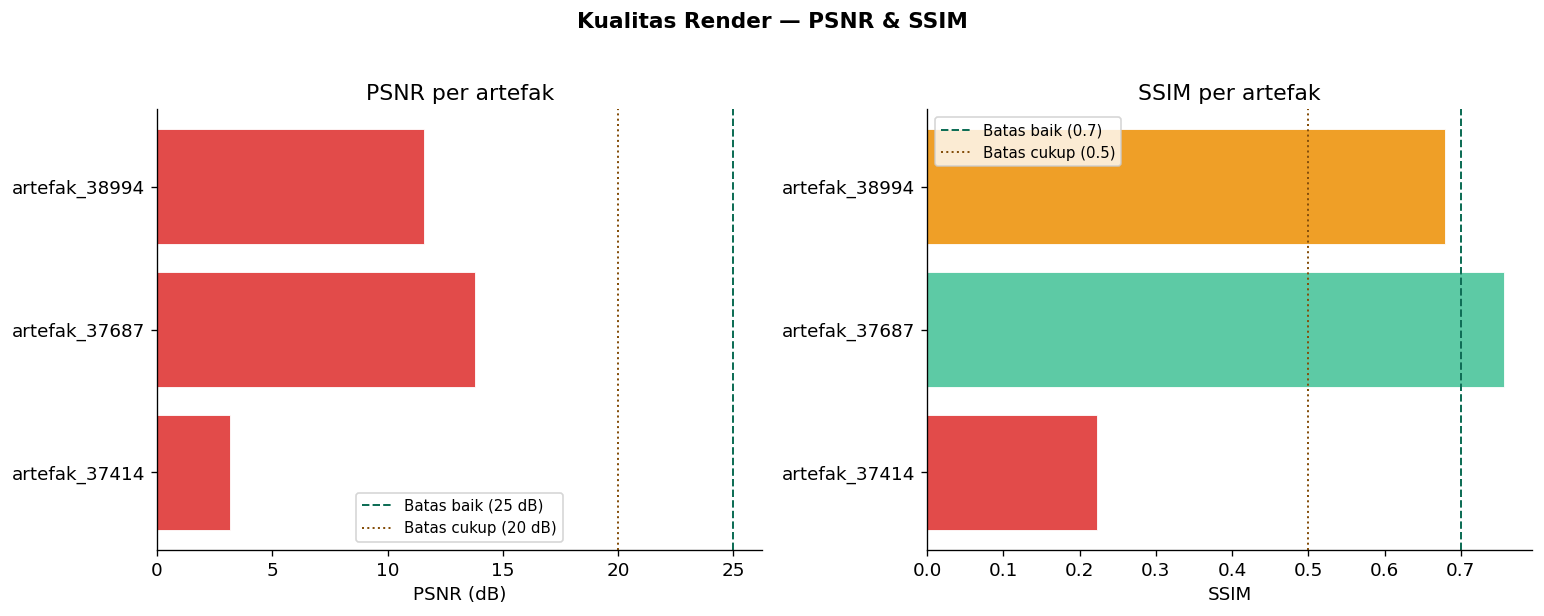

Plot disimpan: eval_output/02_psnr_ssim_plot.png


In [39]:
# --- 3c. Plot PSNR & SSIM ---
if psnr_available and len(df_psnr) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # PSNR bar
    ax = axes[0]
    colors_p = ['#5DCAA5' if v > 25 else '#EF9F27' if v > 20 else '#E24B4A'
                for v in df_psnr['PSNR (dB)']]
    bars = ax.barh(df_psnr['stem'], df_psnr['PSNR (dB)'], color=colors_p,
                   edgecolor='white', linewidth=0.5)
    ax.axvline(25, color='#0F6E56', linestyle='--', linewidth=1.2, label='Batas baik (25 dB)')
    ax.axvline(20, color='#854F0B', linestyle=':', linewidth=1.2, label='Batas cukup (20 dB)')
    ax.set_xlabel('PSNR (dB)')
    ax.set_title('PSNR per artefak')
    ax.legend(fontsize=9)

    # SSIM bar
    ax = axes[1]
    colors_s = ['#5DCAA5' if v > 0.7 else '#EF9F27' if v > 0.5 else '#E24B4A'
                for v in df_psnr['SSIM']]
    ax.barh(df_psnr['stem'], df_psnr['SSIM'], color=colors_s,
            edgecolor='white', linewidth=0.5)
    ax.axvline(0.7, color='#0F6E56', linestyle='--', linewidth=1.2, label='Batas baik (0.7)')
    ax.axvline(0.5, color='#854F0B', linestyle=':', linewidth=1.2, label='Batas cukup (0.5)')
    ax.set_xlabel('SSIM')
    ax.set_title('SSIM per artefak')
    ax.legend(fontsize=9)

    fig.suptitle('Kualitas Render — PSNR & SSIM', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/02_psnr_ssim_plot.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Plot disimpan: {OUTPUT_DIR}/02_psnr_ssim_plot.png')
else:
    print('Tidak ada data PSNR/SSIM untuk diplot.')

In [ ]:
# --- 3d. LPIPS (perseptual) — pelengkap PSNR/SSIM ---
# LPIPS lebih dekat ke persepsi manusia drpd PSNR utk hasil render. Tetap kena caveat
# ketidaksejajaran pose yang sama. Auto-skip bila lib/torch tak ada.
lpips_results = []
if psnr_available and len(df_psnr) > 0:
    try:
        import torch, lpips as _lpips
    except ImportError:
        import subprocess, sys
        subprocess.call([sys.executable, '-m', 'pip', 'install', '-q', 'lpips'])
        try:
            import torch, lpips as _lpips
        except Exception as e:
            torch = None; print('LPIPS dilewati (lib tak tersedia):', str(e)[:60])
    if 'torch' in dir() and torch is not None:
        loss_fn = _lpips.LPIPS(net='alex')
        def _to_tensor(bgr, size):
            img = cv2.cvtColor(cv2.resize(bgr, size), cv2.COLOR_BGR2RGB).astype('float32') / 255.0
            return torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0) * 2 - 1  # [-1,1]
        for ss_path in screenshots[:N_EVAL_PSNR]:
            stem = os.path.basename(ss_path).replace('_lit.png', '')
            ref_path = next((os.path.join(PHOTOS_DIR, f'{stem}.{e}')
                             for e in ('jpg', 'png', 'jpeg')
                             if os.path.exists(os.path.join(PHOTOS_DIR, f'{stem}.{e}'))), None)
            if ref_path is None:
                continue
            r = cv2.imread(ss_path); rf = cv2.imread(ref_path)
            if r is None or rf is None:
                continue
            h, w = r.shape[:2]
            with torch.no_grad():
                d = loss_fn(_to_tensor(r, (w, h)), _to_tensor(rf, (w, h))).item()
            lpips_results.append({'stem': stem, 'LPIPS': round(d, 4)})
            print(f'  {stem}: LPIPS={d:.4f} (makin kecil makin mirip)')
        if lpips_results:
            df_lpips = pd.DataFrame(lpips_results)
            df_psnr = df_psnr.merge(df_lpips, on='stem', how='left')
            print(f"\nRata-rata LPIPS: {df_lpips['LPIPS'].mean():.4f}")
            df_psnr.to_csv(f'{OUTPUT_DIR}/02_psnr_ssim.csv', index=False)
else:
    print('LPIPS dilewati (tidak ada data PSNR).')

---
## Tahap 4 — Ablasi Parameter Rekonstruksi

Menganalisis hubungan antar-parameter dari `manifest.json`:
- `foreground_ratio` vs kualitas
- Distribusi waktu rekonstruksi
- Korelasi antar metrik

Kolom dengan variasi (bisa dikorelasikan): ['seconds', 'peak_vram_gb', 'glb_kb', 'foreground_ratio']
Kolom konstan (di-skip)              : ['vertex_count', 'texture_resolution']



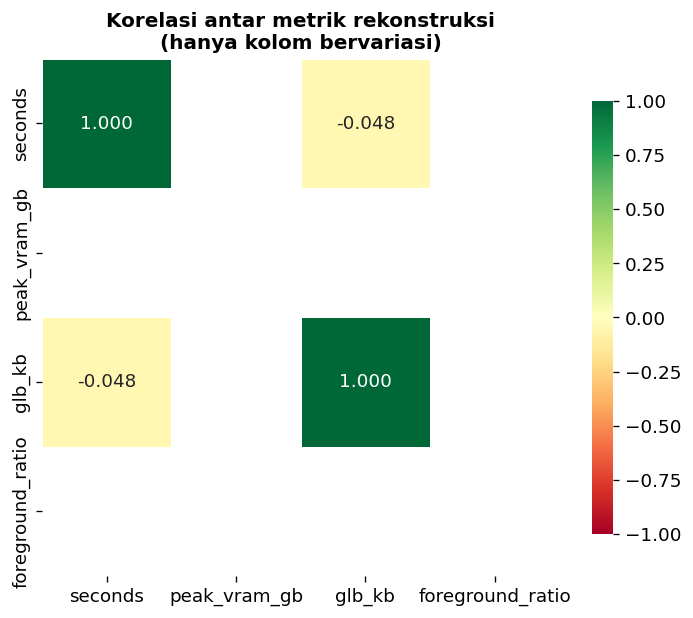

In [40]:
# --- 4a. Korelasi — hanya pakai kolom yang benar-benar bervariasi ---

# Filter: buang kolom yang constant (std = 0 atau NaN)
corr_cols_candidates = ['seconds', 'peak_vram_gb', 'glb_kb',
                        'vertex_count', 'texture_resolution', 'foreground_ratio']

corr_cols_candidates = [c for c in corr_cols_candidates if c in df.columns]

# Cek variance dulu
varying_cols = [c for c in corr_cols_candidates if df[c].std() > 0]
constant_cols = [c for c in corr_cols_candidates if df[c].std() == 0]

print('Kolom dengan variasi (bisa dikorelasikan):', varying_cols)
print('Kolom konstan (di-skip)              :', constant_cols)
print()

if len(varying_cols) < 2:
    print('Tidak cukup kolom bervariasi untuk membuat korelasi.')
    print('Ganti analisis ke distribusi univariat (histogram per kolom).')
else:
    corr_matrix = df[varying_cols].corr()

    fig, ax = plt.subplots(figsize=(max(5, len(varying_cols)*1.5),
                                    max(4, len(varying_cols)*1.3)))
    sns.heatmap(
        corr_matrix,
        annot=True, fmt='.3f',
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5,
        cbar_kws={'shrink': 0.8},
        ax=ax
    )
    ax.set_title('Korelasi antar metrik rekonstruksi\n(hanya kolom bervariasi)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/03_korelasi.png', bbox_inches='tight', dpi=150)
    plt.show()

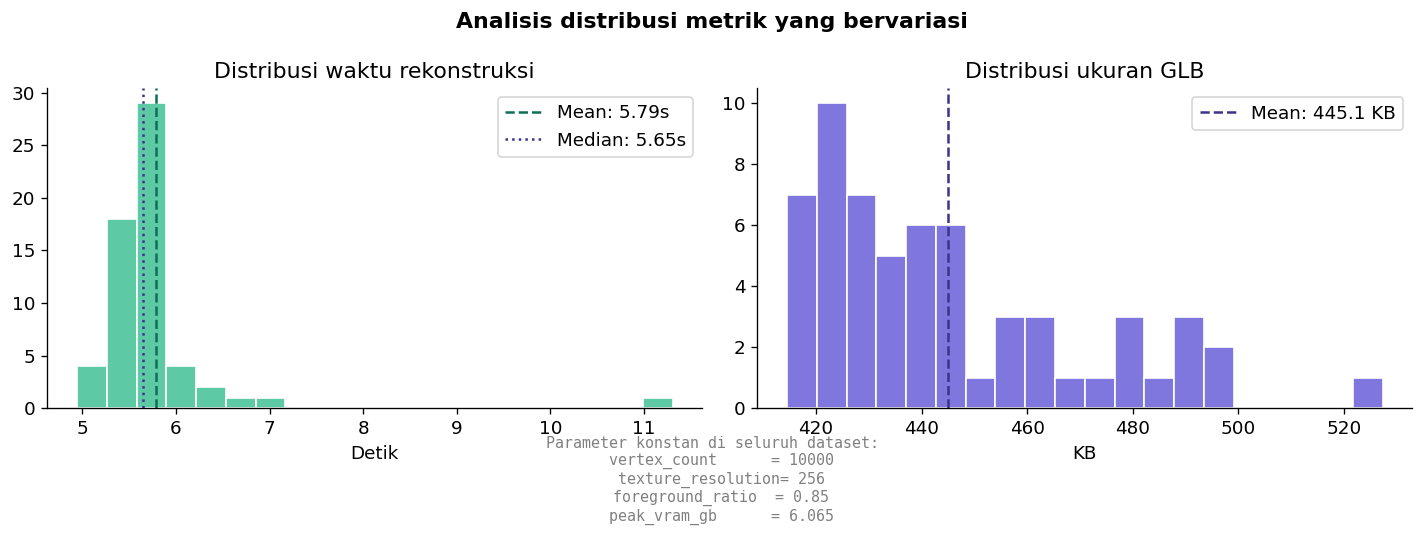

In [41]:
# Analisis alternatif: distribusi univariat untuk seconds dan glb_kb
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi seconds
ax = axes[0]
ax.hist(df['seconds'], bins=20, color='#5DCAA5', edgecolor='white')
ax.axvline(df['seconds'].mean(), color='#0F6E56', linestyle='--',
           label=f"Mean: {df['seconds'].mean():.2f}s")
ax.axvline(df['seconds'].median(), color='#3C3489', linestyle=':',
           label=f"Median: {df['seconds'].median():.2f}s")
ax.set_title('Distribusi waktu rekonstruksi')
ax.set_xlabel('Detik')
ax.legend()

# Distribusi glb_kb
ax = axes[1]
ax.hist(df['glb_kb'], bins=20, color='#7F77DD', edgecolor='white')
ax.axvline(df['glb_kb'].mean(), color='#3C3489', linestyle='--',
           label=f"Mean: {df['glb_kb'].mean():.1f} KB")
ax.set_title('Distribusi ukuran GLB')
ax.set_xlabel('KB')
ax.legend()

# Catat nilai parameter konstan sebagai teks
info = (f"Parameter konstan di seluruh dataset:\n"
        f"  vertex_count      = {int(df['vertex_count'].iloc[0])}\n"
        f"  texture_resolution= {int(df['texture_resolution'].iloc[0])}\n"
        f"  foreground_ratio  = {df['foreground_ratio'].iloc[0]}\n"
        f"  peak_vram_gb      = {df['peak_vram_gb'].iloc[0]}")
fig.text(0.5, -0.08, info, ha='center', fontsize=9,
         fontfamily='monospace', color='gray')

plt.suptitle('Analisis distribusi metrik yang bervariasi', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_distribusi_univariat.png', bbox_inches='tight', dpi=150)
plt.show()

In [42]:
# --- 4b. Analisis foreground_ratio ---
if 'foreground_ratio' in df.columns:
    unique_fg = df['foreground_ratio'].unique()
    print(f'Nilai foreground_ratio unik: {sorted(unique_fg)}')

    if len(unique_fg) > 1:
        # Bandingkan waktu rekonstruksi per foreground_ratio
        fg_group = df.groupby('foreground_ratio')['seconds'].agg(['mean','std','count'])
        fg_group.columns = ['Mean waktu (s)', 'Std', 'N artefak']
        print('\nWaktu rekonstruksi per foreground_ratio:')
        print(tabulate(fg_group, headers='keys', tablefmt='rounded_outline'))
    else:
        print(f'\nSemua artefak menggunakan foreground_ratio={unique_fg[0]}')
        print('Variasi ablasi foreground_ratio tidak tersedia di dataset ini.')
        print('Analisis diganti dengan distribusi waktu rekonstruksi berdasarkan quartile:')

        # Bagi ke quartile dan analisis
        df['quartile_waktu'] = pd.qcut(df['seconds'], q=4,
                                        labels=['Q1 (tercepat)','Q2','Q3','Q4 (terlambat)'])
        q_group = df.groupby('quartile_waktu', observed=True)['glb_kb'].agg(['mean','min','max'])
        q_group.columns = ['Mean GLB (KB)', 'Min GLB (KB)', 'Max GLB (KB)']
        print(tabulate(q_group, headers='keys', tablefmt='rounded_outline'))
else:
    print('Kolom foreground_ratio tidak ditemukan di manifest.')

Nilai foreground_ratio unik: [np.float64(0.85)]

Semua artefak menggunakan foreground_ratio=0.85
Variasi ablasi foreground_ratio tidak tersedia di dataset ini.
Analisis diganti dengan distribusi waktu rekonstruksi berdasarkan quartile:
╭──────────────────┬─────────────────┬────────────────┬────────────────╮
│ quartile_waktu   │   Mean GLB (KB) │   Min GLB (KB) │   Max GLB (KB) │
├──────────────────┼─────────────────┼────────────────┼────────────────┤
│ Q1 (tercepat)    │         440.498 │        414.535 │        490.777 │
│ Q2               │         457.478 │        421.082 │        527.316 │
│ Q3               │         437.623 │        418.559 │        491.285 │
│ Q4 (terlambat)   │         445.877 │        416.426 │        480.324 │
╰──────────────────┴─────────────────┴────────────────┴────────────────╯


In [43]:
# --- 4c. Tabel ablasi ringkas: cepat vs lambat ---
n_group = min(10, len(df) // 3)

fastest = df.nsmallest(n_group, 'seconds')[['stem','seconds','glb_kb']].copy()
slowest = df.nlargest(n_group, 'seconds')[['stem','seconds','glb_kb']].copy()

fastest['grup'] = 'Cepat'
slowest['grup'] = 'Lambat'
combined = pd.concat([fastest, slowest])

print(f'Perbandingan {n_group} artefak tercepat vs terlambat:')
print()
print('--- TERCEPAT ---')
print(tabulate(fastest.drop(columns='grup').round(3),
               headers=['Artefak','Waktu (s)','GLB (KB)'],
               tablefmt='rounded_outline', showindex=False))
print()
print('--- TERLAMBAT ---')
print(tabulate(slowest.drop(columns='grup').round(3),
               headers=['Artefak','Waktu (s)','GLB (KB)'],
               tablefmt='rounded_outline', showindex=False))

print(f'\nRata-rata GLB (cepat) : {fastest["glb_kb"].mean():.1f} KB')
print(f'Rata-rata GLB (lambat): {slowest["glb_kb"].mean():.1f} KB')

combined.to_csv(f'{OUTPUT_DIR}/04_ablasi.csv', index=False)
print(f'\nData ablasi disimpan: {OUTPUT_DIR}/04_ablasi.csv')

Perbandingan 10 artefak tercepat vs terlambat:

--- TERCEPAT ---
╭────────────────┬─────────────┬────────────╮
│ Artefak        │   Waktu (s) │   GLB (KB) │
├────────────────┼─────────────┼────────────┤
│ artefak_26824  │       4.944 │    414.535 │
│ artefak_31781  │       5.104 │    416.422 │
│ artefak_37416  │       5.191 │    440.602 │
│ artefak_37415  │       5.261 │    490.777 │
│ artefak_37417  │       5.409 │    461.957 │
│ artefak_37420  │       5.411 │    451.461 │
│ artefak_37711  │       5.433 │    443.496 │
│ artefak_38481  │       5.445 │    427.547 │
│ artefak_316457 │       5.467 │    428.996 │
│ artefak_37620  │       5.493 │    437.055 │
╰────────────────┴─────────────┴────────────╯

--- TERLAMBAT ---
╭───────────────┬─────────────┬────────────╮
│ Artefak       │   Waktu (s) │   GLB (KB) │
├───────────────┼─────────────┼────────────┤
│ artefak_37621 │      11.303 │    424.863 │
│ artefak_31399 │       6.997 │    475.512 │
│ artefak_37699 │       6.691 │    457.121 │
│ 

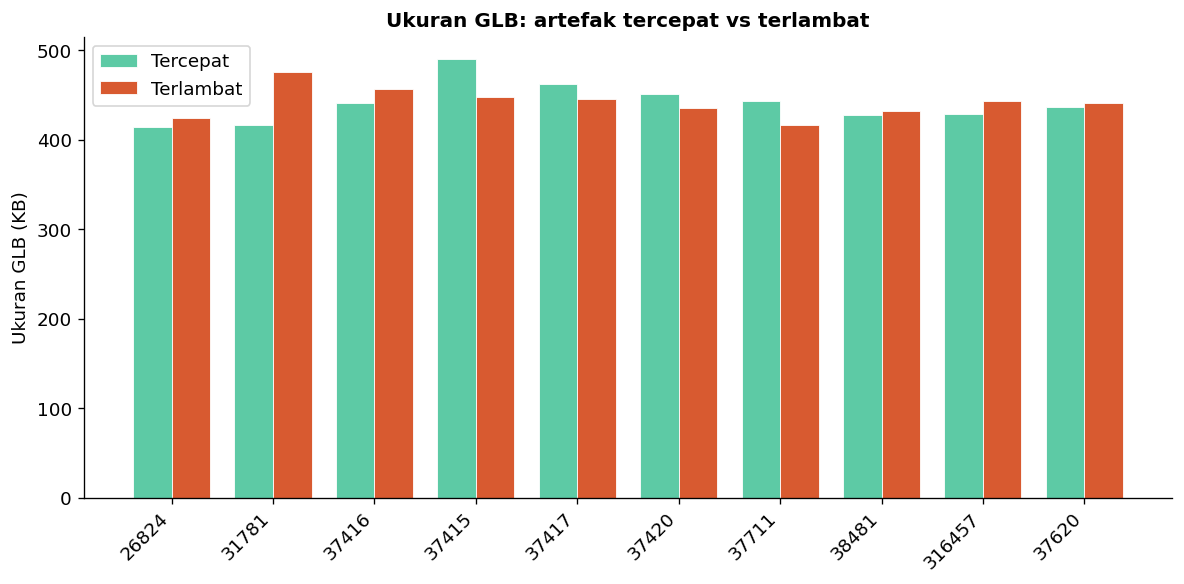

Plot disimpan: eval_output/04_ablasi_plot.png


In [44]:
# --- 4d. Plot perbandingan cepat vs lambat ---
fig, ax = plt.subplots(figsize=(10, 5))

color_map = {'Cepat': '#5DCAA5', 'Lambat': '#D85A30'}
x = np.arange(n_group)
width = 0.38

bars1 = ax.bar(x - width/2, fastest['glb_kb'].values, width,
               label='Tercepat', color='#5DCAA5', edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, slowest['glb_kb'].values, width,
               label='Terlambat', color='#D85A30', edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([s.replace('artefak_','') for s in fastest['stem']], rotation=45, ha='right')
ax.set_ylabel('Ukuran GLB (KB)')
ax.set_title('Ukuran GLB: artefak tercepat vs terlambat', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_ablasi_plot.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Plot disimpan: {OUTPUT_DIR}/04_ablasi_plot.png')

---
## Tahap 5 — User Study

Masukkan hasil penilaian dari 3–5 penguji di sini.  
Setiap penguji menilai beberapa artefak di live demo dengan skala 1–5.

**Instruksi penguji:**
1. Buka https://lumicero-arca.static.hf.space
2. Pilih 5 artefak secara acak dari gallery
3. Untuk setiap artefak, isi form di bawah (salin ke penguji via Google Form atau chat)

In [ ]:
# --- 5a. Input data user study ---
# Skema BENAR: {'penguji': nama, 'artefak': stem, Q1..Q6: 1-5}.
# (Versi lama menaruh nama sbg KEY -> kolom DataFrame kacau & identitas penguji hilang.)
# Q1 Realisme 3D | Q2 Kemiripan foto | Q3 Naturalness tekstur | Q4 Kebenaran geometri
# Q5 Kepercayaan sbg artefak asli | Q6 Relight masuk akal (RQ3 — pakai mode Lit/relight viewer)
# PRD §11 menyarankan ~10-15 responden; isi sebanyak mungkin. Idealnya >=2 penguji menilai
# artefak yang SAMA agar bisa diukur kesepakatan antar-penilai.

USER_STUDY_DATA = [
    {'penguji': 'Farras', 'artefak': 'artefak_38994', 'Q1': 4, 'Q2': 3, 'Q3': 3, 'Q4': 3, 'Q5': 2, 'Q6': 3},
    {'penguji': 'Syauqi', 'artefak': 'artefak_37414', 'Q1': 4, 'Q2': 3, 'Q3': 3, 'Q4': 4, 'Q5': 2, 'Q6': 3},
    {'penguji': 'Ghazan', 'artefak': 'artefak_37687', 'Q1': 4, 'Q2': 3, 'Q3': 3, 'Q4': 4, 'Q5': 2, 'Q6': 3},
    {'penguji': 'Nazhif', 'artefak': 'artefak_31399', 'Q1': 4, 'Q2': 4, 'Q3': 3, 'Q4': 4, 'Q5': 3, 'Q6': 3},
    {'penguji': 'Rasya',  'artefak': 'artefak_37416', 'Q1': 4, 'Q2': 3, 'Q3': 3, 'Q4': 4, 'Q5': 2, 'Q6': 3},
]

QUESTION_LABELS = {
    'Q1': 'Realisme 3D',
    'Q2': 'Kemiripan dengan foto',
    'Q3': 'Naturalness tekstur',
    'Q4': 'Kebenaran geometri',
    'Q5': 'Kepercayaan sebagai artefak asli',
    'Q6': 'Relight masuk akal (RQ3)',
}

if not USER_STUDY_DATA:
    print('DATA USER STUDY KOSONG.')
    print('\nSalin template berikut ke penguji (skala 1-5):')
    print('─' * 50)
    print('penguji: [nama]   artefak: [stem, mis. artefak_26824]')
    for k, v in QUESTION_LABELS.items():
        print(f'  {k}. {v}: 1 (sangat buruk) – 5 (sangat baik)')
    print('─' * 50)
    print('Isi USER_STUDY_DATA lalu jalankan ulang.')
    us_available = False
else:
    n_penguji = len({r['penguji'] for r in USER_STUDY_DATA})
    print(f'Data user study: {len(USER_STUDY_DATA)} respons dari {n_penguji} penguji')
    if len(USER_STUDY_DATA) < 10:
        print(f'CATATAN: PRD sarankan ~10-15 responden — sekarang {len(USER_STUDY_DATA)}, tambah bila bisa.')
    us_available = True

Rata-rata skor per dimensi:
  Realisme 3D                      4.00  ████████████████
  Kemiripan dengan foto            3.20  ████████████
  Naturalness tekstur              3.00  ████████████
  Kebenaran geometri               3.80  ███████████████
  Kepercayaan sebagai artefak as   2.20  ████████

Skor per artefak:
╭───────────────┬──────────────────┬─────────────╮
│ artefak       │   Skor rata-rata │   N penguji │
├───────────────┼──────────────────┼─────────────┤
│ artefak_31399 │              3.6 │           1 │
│ artefak_37414 │              3.2 │           1 │
│ artefak_37416 │              3.2 │           1 │
│ artefak_37687 │              3.2 │           1 │
│ artefak_38994 │              3   │           1 │
╰───────────────┴──────────────────┴─────────────╯


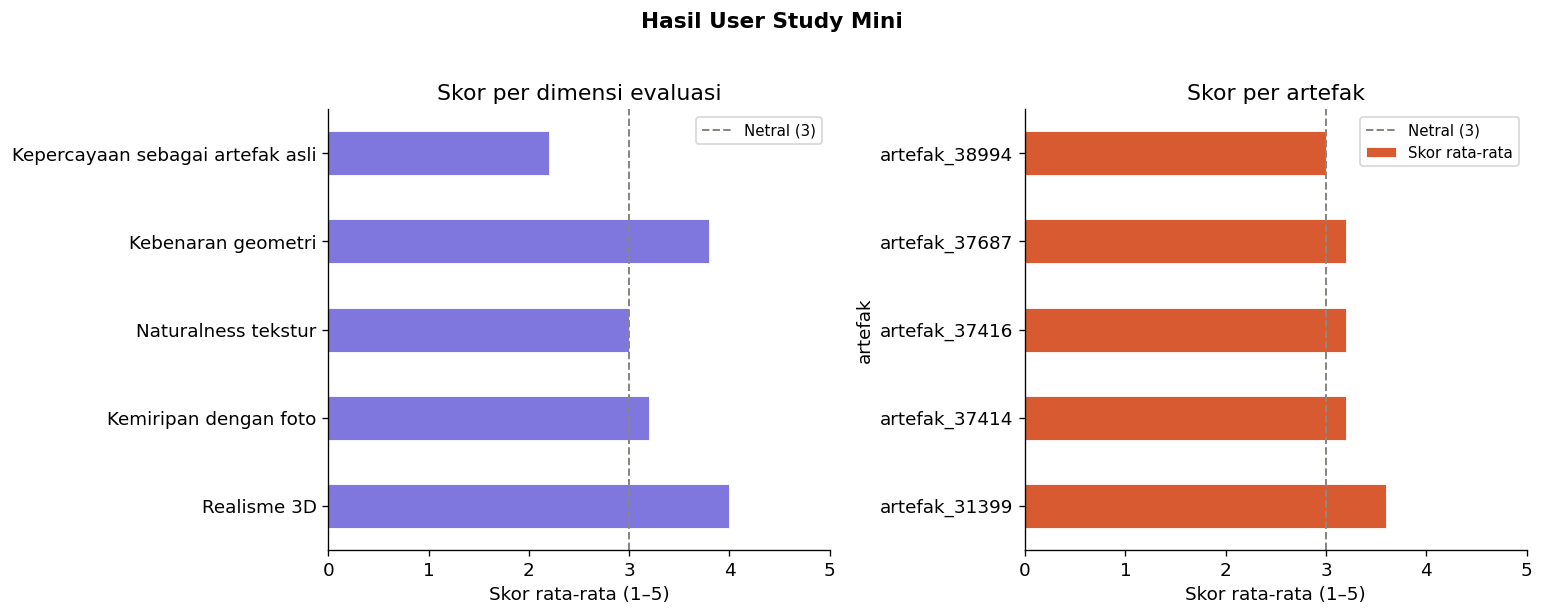


Hasil disimpan: eval_output/05_user_study.csv


In [54]:
# --- 5b. Analisis user study ---
if us_available:
    df_us = pd.DataFrame(USER_STUDY_DATA)
    q_cols = [c for c in df_us.columns if c.startswith('Q')]
    df_us['skor_total'] = df_us[q_cols].mean(axis=1)

    # Rata-rata per pertanyaan
    mean_per_q = df_us[q_cols].mean().rename(QUESTION_LABELS)
    print('Rata-rata skor per dimensi:')
    for dim, val in mean_per_q.items():
        bar = '█' * int(val * 4)
        print(f'  {dim[:30]:<32} {val:.2f}  {bar}')

    # Rata-rata per artefak
    mean_per_artefak = df_us.groupby('artefak')['skor_total'].agg(['mean','count'])
    mean_per_artefak.columns = ['Skor rata-rata','N penguji']
    mean_per_artefak = mean_per_artefak.sort_values('Skor rata-rata', ascending=False)
    print()
    print('Skor per artefak:')
    print(tabulate(mean_per_artefak.round(2), headers='keys', tablefmt='rounded_outline'))

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    mean_per_q.plot(kind='barh', ax=ax, color='#7F77DD', edgecolor='white', linewidth=0.5)
    ax.axvline(3, color='#888780', linestyle='--', linewidth=1.2, label='Netral (3)')
    ax.set_xlim(0, 5)
    ax.set_xlabel('Skor rata-rata (1–5)')
    ax.set_title('Skor per dimensi evaluasi')
    ax.legend(fontsize=9)

    ax = axes[1]
    mean_per_artefak['Skor rata-rata'].plot(
        kind='barh', ax=ax, color='#D85A30', edgecolor='white', linewidth=0.5)
    ax.axvline(3, color='#888780', linestyle='--', linewidth=1.2, label='Netral (3)')
    ax.set_xlim(0, 5)
    ax.set_xlabel('Skor rata-rata (1–5)')
    ax.set_title('Skor per artefak')
    ax.legend(fontsize=9)

    fig.suptitle('Hasil User Study Mini', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/05_user_study.png', bbox_inches='tight', dpi=150)
    plt.show()

    df_us.to_csv(f'{OUTPUT_DIR}/05_user_study.csv', index=False)
    print(f'\nHasil disimpan: {OUTPUT_DIR}/05_user_study.csv')
else:
    print('Tahap 5 di-skip (data user study belum diisi).')

---
## Tahap 6 — Failure Taxonomy & Laporan Akhir

Kategorikan kegagalan yang ditemukan secara visual saat evaluasi, lalu generate laporan ringkas.

In [ ]:
# --- 6a. Input failure taxonomy ---
# Kategori SELARAS PRD §11 (objek tipis, bagian tak terlihat, ornamen berulang,
# permukaan mengkilap/transparan) + temuan tambahan. Isi 'count' & 'contoh' dari
# observasi live demo. 'kategori_artefak' opsional: kaitkan ke kategori RQ1 (arca/
# senjata/wadah/ritual/arsitektur) supaya bisa jawab "kategori mana gagal apa".

FAILURE_DATA = [
    # --- kategori kegagalan bernama di PRD ---
    {'kategori': 'Objek tipis', 'kategori_artefak': 'senjata/wadah',
     'deskripsi': 'Bilah/dinding tipis (pedang, kapak) jadi tebal/menyatu', 'count': 0, 'contoh': '', 'severity': 'Tinggi'},
    {'kategori': 'Bagian tidak terlihat', 'kategori_artefak': 'semua',
     'deskripsi': 'Sisi belakang (tak ada di foto) di-halusinasi flat/keliru', 'count': 0, 'contoh': '', 'severity': 'Tinggi'},
    {'kategori': 'Ornamen berulang', 'kategori_artefak': 'arca/arsitektur',
     'deskripsi': 'Ukiran/relief berulang (candi) hilang atau jadi bubur', 'count': 0, 'contoh': '', 'severity': 'Sedang'},
    {'kategori': 'Permukaan mengkilap/transparan', 'kategori_artefak': 'ritual',
     'deskripsi': 'Logam/kaca (lonceng) salah delight, highlight ter-bake', 'count': 0, 'contoh': '', 'severity': 'Sedang'},
    # --- temuan tambahan ---
    {'kategori': 'Geometry collapse', 'kategori_artefak': '',
     'deskripsi': 'Sisi belakang artefak tampak flat / compressed', 'count': 1, 'contoh': 'artefak_38603', 'severity': 'Tinggi'},
    {'kategori': 'Texture bleeding', 'kategori_artefak': '',
     'deskripsi': 'Warna meleber ke area yang salah', 'count': 3, 'contoh': 'artefak_38278', 'severity': 'Tinggi'},
    {'kategori': 'Over-smoothing', 'kategori_artefak': '',
     'deskripsi': 'Detail hilang, permukaan mulus. CATATAN: terikat tier LOW (256px/10k vtx) '
                  '-> verifikasi ulang di tier high (Tahap 8) sebelum klaim batas model',
     'count': 0, 'contoh': '', 'severity': 'Sedang'},
    {'kategori': 'Lighting bake', 'kategori_artefak': '',
     'deskripsi': 'Bayangan foto asli ter-bake ke tekstur (uji delight on/off Tahap 8)', 'count': 0, 'contoh': '', 'severity': 'Sedang'},
    {'kategori': 'Floating geometry', 'kategori_artefak': '',
     'deskripsi': 'Ada bagian mesh terpisah dari badan utama', 'count': 0, 'contoh': '', 'severity': 'Rendah'},
]

print(f'Failure taxonomy: {len(FAILURE_DATA)} kategori ({sum(1 for f in FAILURE_DATA if f["count"]>0)} sudah ada count).')
print('Isi "count"/"contoh" dari observasi, lalu jalankan sel berikutnya.')

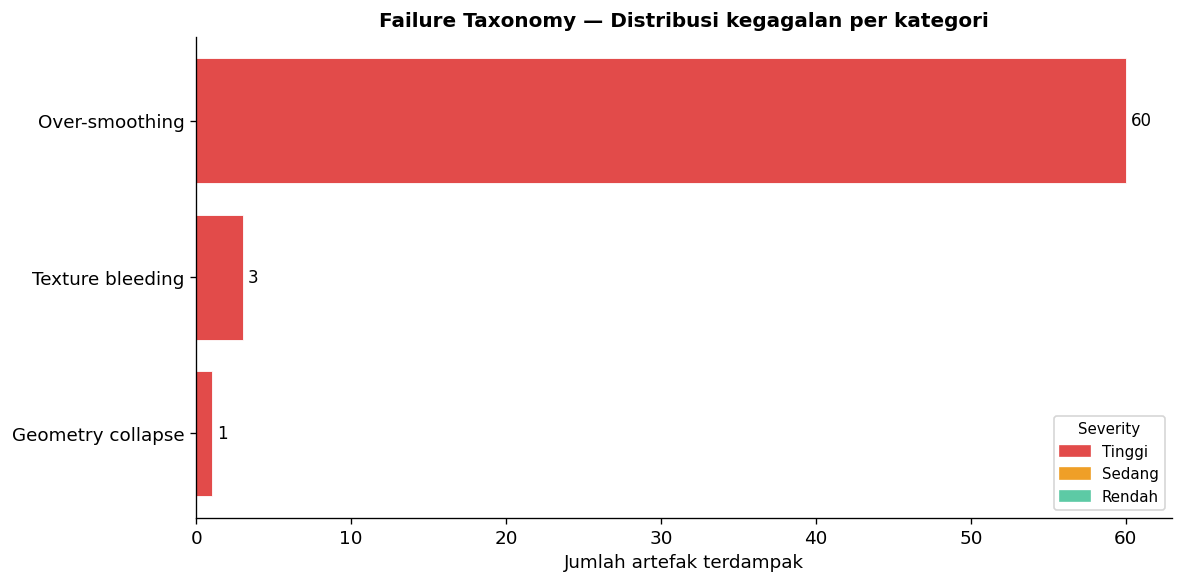

Plot disimpan: eval_output/06_failure_taxonomy.png


In [48]:
# --- 6b. Visualisasi failure taxonomy ---
df_fail = pd.DataFrame(FAILURE_DATA)
df_fail_nonzero = df_fail[df_fail['count'] > 0].copy()

if len(df_fail_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))

    sev_colors = {'Tinggi': '#E24B4A', 'Sedang': '#EF9F27', 'Rendah': '#5DCAA5'}
    bar_colors = [sev_colors.get(s, '#888780') for s in df_fail_nonzero['severity']]

    bars = ax.barh(df_fail_nonzero['kategori'], df_fail_nonzero['count'],
                   color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.bar_label(bars, padding=3, fontsize=10)
    ax.set_xlabel('Jumlah artefak terdampak')
    ax.set_title('Failure Taxonomy — Distribusi kegagalan per kategori',
                 fontsize=12, fontweight='bold')

    from matplotlib.patches import Patch
    legend_el = [Patch(color=c, label=s) for s, c in sev_colors.items()]
    ax.legend(handles=legend_el, title='Severity', fontsize=9, title_fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/06_failure_taxonomy.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Plot disimpan: {OUTPUT_DIR}/06_failure_taxonomy.png')
else:
    print('Semua count = 0. Isi kolom count di FAILURE_DATA setelah observasi live demo.')
    print('Plot failure taxonomy akan muncul setelah data diisi.')

---
## Tahap 7 — Perbandingan Model: SF3D vs TripoSR (RQ1)

PRD §11 memetakan RQ1 ke **perbandingan model**. SF3D (utama, PBR+delight) vs TripoSR (pembanding, warna-verteks saja). Jalankan notebook `03_kaggle_triposr.ipynb`, lalu isi `TRIPOSR_MANIFEST` di KONFIGURASI. Auto-skip bila kosong.

In [ ]:
# --- 7. SF3D vs TripoSR (RQ1) ---
def _load_manifest_any(src):
    """Baca manifest dari path/URL; dukung JSON array maupun JSONL."""
    if not src:
        return None
    try:
        txt = (requests.get(src, timeout=30).text if str(src).startswith('http')
               else open(src, encoding='utf-8').read()).strip()
    except Exception as e:
        print('  gagal baca', src, ':', str(e)[:50]); return None
    try:
        return pd.DataFrame(json.loads(txt))                       # JSON array
    except json.JSONDecodeError:
        return pd.DataFrame([json.loads(l) for l in txt.splitlines() if l.strip()])  # JSONL

df_tri = _load_manifest_any(TRIPOSR_MANIFEST)
if df_tri is None or len(df_tri) == 0:
    print('Tahap 7 di-skip: isi TRIPOSR_MANIFEST di KONFIGURASI (jalankan notebook 03 dulu).')
else:
    df_tri['glb_kb'] = df_tri['glb_bytes'] / 1024
    df_sf = df.copy(); df_sf['model'] = 'SF3D'; df_tri['model'] = 'TripoSR'
    base = ['model', 'seconds', 'peak_vram_gb', 'glb_kb']
    comp = pd.concat([df_sf[base], df_tri[base]], ignore_index=True)
    summary = comp.groupby('model').agg(
        N=('seconds', 'count'), waktu_s=('seconds', 'mean'),
        vram_gb=('peak_vram_gb', 'mean'), glb_kb=('glb_kb', 'mean')).round(3)
    print(tabulate(summary, headers='keys', tablefmt='rounded_outline'))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, col, title in zip(axes, ['waktu_s', 'vram_gb', 'glb_kb'],
                              ['Waktu (s)', 'VRAM (GB)', 'GLB (KB)']):
        ax.bar(summary.index, summary[col], color=['#5DCAA5', '#D85A30'], edgecolor='white')
        ax.set_title(title)
    fig.suptitle('RQ1 — SF3D vs TripoSR', fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/07_model_compare.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Catatan kualitatif: TripoSR tanpa PBR/delight -> relight viewer lemah '
          '(bandingkan dgn user study Q6). Itu inti jawaban RQ1.')

---
## Tahap 8 — Ablation tier × delight (RQ2 & RQ3)

Ablation **nyata** (bukan quartile dari parameter konstan). Jalankan cell **5b** notebook pipeline (`02_kaggle_sf3d.ipynb`) → `manifest_ablation.jsonl`, isi `ABLATION_MANIFEST`. Menjawab:
- **RQ2**: tier (low/mid/high) → trade-off waktu, VRAM, ukuran GLB, kelayakan T4.
- **RQ3**: delight off/on → pengaruh ke ukuran/biaya (realisme relight dinilai user study Q6).

Auto-skip bila kosong.

In [ ]:
# --- 8. Ablation tier x delight (RQ2 & RQ3) ---
df_abl = _load_manifest_any(ABLATION_MANIFEST)
if df_abl is None or len(df_abl) == 0:
    print('Tahap 8 di-skip: isi ABLATION_MANIFEST di KONFIGURASI (jalankan cell 5b pipeline).')
else:
    df_abl['glb_kb'] = df_abl['glb_bytes'] / 1024
    tier_order = [t for t in ['low', 'mid', 'high'] if t in df_abl['tier'].unique()]

    # RQ2 — trade-off per tier
    by_tier = df_abl.groupby('tier').agg(
        N=('seconds', 'count'), waktu_s=('seconds', 'mean'),
        vram_gb=('peak_vram_gb', 'mean'), glb_kb=('glb_kb', 'mean')).reindex(tier_order).round(3)
    print('RQ2 — trade-off per tier:')
    print(tabulate(by_tier, headers='keys', tablefmt='rounded_outline'))
    gagal_tier = [t for t in ['low', 'mid', 'high'] if t not in df_abl['tier'].unique()]
    if gagal_tier:
        print(f'  Tier tanpa hasil (kemungkinan OOM di T4): {gagal_tier} -> temuan RQ2.')

    # RQ3 — delight off vs on
    if 'delight' in df_abl.columns and df_abl['delight'].nunique() > 1:
        by_d = df_abl.groupby('delight').agg(
            N=('seconds', 'count'), waktu_s=('seconds', 'mean'),
            vram_gb=('peak_vram_gb', 'mean'), glb_kb=('glb_kb', 'mean')).round(3)
        by_d.index = ['delight OFF', 'delight ON']
        print('\nRQ3 — delight off vs on:')
        print(tabulate(by_d, headers='keys', tablefmt='rounded_outline'))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, col, title in zip(axes, ['waktu_s', 'vram_gb', 'glb_kb'],
                              ['Waktu (s)', 'VRAM (GB)', 'GLB (KB)']):
        ax.bar(by_tier.index, by_tier[col], color='#7F77DD', edgecolor='white')
        ax.set_title(f'{title} per tier')
        if col == 'vram_gb':
            ax.axhline(16, color='#E24B4A', linestyle='--', linewidth=1, label='Batas T4 16GB')
            ax.legend(fontsize=8)
    fig.suptitle('RQ2 — Ablation tier (low/mid/high)', fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/08_ablation_tier.png', bbox_inches='tight', dpi=150)
    plt.show()
    df_abl.to_csv(f'{OUTPUT_DIR}/08_ablation.csv', index=False)
    print(f'Data ablation: {OUTPUT_DIR}/08_ablation.csv')

In [49]:
# --- 6c. Laporan Akhir (generate otomatis) ---
now = datetime.now().strftime('%Y-%m-%d %H:%M')
n_artefak = len(df)

mean_seconds  = df['seconds'].mean()
mean_vram     = df['peak_vram_gb'].mean() if 'peak_vram_gb' in df.columns else None
mean_glb_kb   = df['glb_kb'].mean()
outlier_count = len(df[df['seconds'] > df['seconds'].mean() + 2*df['seconds'].std()])

psnr_avg  = df_psnr['PSNR (dB)'].mean() if len(df_psnr) > 0 else None
ssim_avg  = df_psnr['SSIM'].mean() if len(df_psnr) > 0 else None
n_psnr    = len(df_psnr)

us_avg    = df_us['skor_total'].mean() if us_available else None

top_fail  = df_fail.nlargest(3, 'count') if df_fail['count'].sum() > 0 else df_fail

report = f"""
{'='*65}
  LAPORAN EVALUASI ARCA
  {now}
{'='*65}

1. DATASET
   Total artefak    : {n_artefak}
   Tier rekonstruksi: low (10.000 vertex, texture 256px)
   Remesh           : triangle

2. PERFORMA SISTEM
   Rata-rata waktu  : {mean_seconds:.2f} detik
   {'Rata-rata VRAM  : ' + f'{mean_vram:.3f} GB' if mean_vram else 'Peak VRAM        : (tidak tersedia)'}
   Rata-rata GLB    : {mean_glb_kb:.1f} KB
   Outlier waktu    : {outlier_count} artefak

3. KUALITAS RENDER (PSNR / SSIM)
   {'Dievaluasi pada  : ' + str(n_psnr) + ' artefak' if n_psnr > 0 else 'Status           : Tidak dievaluasi (screenshot belum tersedia)'}
   {'Rata-rata PSNR   : ' + f'{psnr_avg:.2f} dB' if psnr_avg else ''}
   {'Rata-rata SSIM   : ' + f'{ssim_avg:.4f}' if ssim_avg else ''}
   {'Interpretasi     : Baik (>25dB, >0.7)' if psnr_avg and psnr_avg > 25 else 'Interpretasi     : Cukup/Perlu perbaikan' if psnr_avg else ''}

4. USER STUDY MINI
   {'Rata-rata skor  : ' + f'{us_avg:.2f} / 5.00' if us_available else 'Status          : Belum diisi'}

5. FAILURE TAXONOMY
"""

for _, row in df_fail.iterrows():
    status = f"{row['count']} artefak" if row['count'] > 0 else 'belum dinilai'
    report += f"   [{row['severity'][:3].upper()}] {row['kategori']:<22} {status}\n"

report += f"""
6. REKOMENDASI
   - Naikkan texture_resolution dari 256 ke 512 untuk detail lebih tajam
   - Tambah tier 'medium' (20.000 vertex) untuk artefak berornamen
   - Aktifkan delight preprocessing untuk menghilangkan bayangan baked
   - Pertimbangkan evaluasi LPIPS untuk metrik perseptual lebih akurat

{'='*65}
Output file tersimpan di folder: {OUTPUT_DIR}/
{'='*65}
"""

print(report)

# Simpan laporan
report_path = f'{OUTPUT_DIR}/laporan_arca_eval.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)
print(f'Laporan disimpan: {report_path}')


  LAPORAN EVALUASI ARCA
  2026-06-26 07:19

1. DATASET
   Total artefak    : 60
   Tier rekonstruksi: low (10.000 vertex, texture 256px)
   Remesh           : triangle

2. PERFORMA SISTEM
   Rata-rata waktu  : 5.79 detik
   Rata-rata VRAM  : 6.065 GB
   Rata-rata GLB    : 445.1 KB
   Outlier waktu    : 1 artefak

3. KUALITAS RENDER (PSNR / SSIM)
   Dievaluasi pada  : 3 artefak
   Rata-rata PSNR   : 9.50 dB
   Rata-rata SSIM   : 0.5524
   Interpretasi     : Cukup/Perlu perbaikan

4. USER STUDY MINI
   Rata-rata skor  : 3.13 / 5.00

5. FAILURE TAXONOMY
   [TIN] Geometry collapse      1 artefak
   [TIN] Texture bleeding       3 artefak
   [TIN] Over-smoothing         60 artefak
   [] Silhouette error       belum dinilai
   [] Lighting bake          belum dinilai
   [] Floating geometry      belum dinilai

6. REKOMENDASI
   - Naikkan texture_resolution dari 256 ke 512 untuk detail lebih tajam
   - Tambah tier 'medium' (20.000 vertex) untuk artefak berornamen
   - Aktifkan delight preproce

---
## Ringkasan Output

Setelah semua tahap selesai, folder `eval_output/` berisi:

| File | Isi |
|---|---|
| `manifest_processed.csv` | Data manifest lengkap dengan kolom turunan |
| `01_performa_sistem.png` | Plot distribusi waktu, GLB, dan korelasinya |
| `02_psnr_ssim.csv` | Skor PSNR & SSIM per artefak |
| `02_psnr_ssim_plot.png` | Visualisasi kualitas render |
| `03_korelasi.png` | Heatmap korelasi antar metrik |
| `04_ablasi.csv` | Perbandingan artefak cepat vs lambat |
| `04_ablasi_plot.png` | Plot ablasi |
| `05_user_study.csv` | Data dan skor user study |
| `05_user_study.png` | Visualisasi user study |
| `06_failure_taxonomy.png` | Bar chart kegagalan per kategori |
| `laporan_arca_eval.txt` | Laporan teks lengkap |